In [19]:
!pip install optuna mlflow

In [20]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [21]:
cols = ['S1', 'R1', 'S2', 'R2', 'S3', 'R3', 'S4', 'R4', 'S5', 'R5', 'Class']
train_df = pd.read_csv('poker-hand-training-true.data', names=cols)
test_df = pd.read_csv('poker-hand-testing.data', names=cols)

In [22]:
def preprocess_poker_data(df):
    X = df.drop('Class', axis=1).copy()
    y = df['Class']
    suits = X[['S1', 'S2', 'S3', 'S4', 'S5']].values
    ranks = X[['R1', 'R2', 'R3', 'R4', 'R5']].values
    ranks.sort(axis=1)
    unique_suits = [len(np.unique(s)) for s in suits]
    unique_ranks = [len(np.unique(r)) for r in ranks]
    rank_diffs = ranks[:, -1] - ranks[:, 0]
    X_engineered = pd.DataFrame(ranks, columns=['R_sorted1', 'R_sorted2', 'R_sorted3', 'R_sorted4', 'R_sorted5'])
    X_engineered['unique_suits'] = unique_suits
    X_engineered['unique_ranks'] = unique_ranks
    X_engineered['rank_spread'] = rank_diffs
    return X_engineered, y

X_train, y_train = preprocess_poker_data(train_df)
X_test, y_test = preprocess_poker_data(test_df)

In [23]:
pipeline = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',
        random_state=42
    ))
])

In [24]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       0.95      0.99      0.97     47622
           3       0.96      0.89      0.93     21121
           4       1.00      1.00      1.00      3885
           5       1.00      0.99      0.99      1996
           6       0.90      1.00      0.94      1424
           7       1.00      0.17      0.29       230
           8       0.33      0.42      0.37        12
           9       0.38      1.00      0.55         3

    accuracy                           1.00   1000000
   macro avg       0.85      0.85      0.80   1000000
weighted avg       1.00      1.00      1.00   1000000



Chart 1

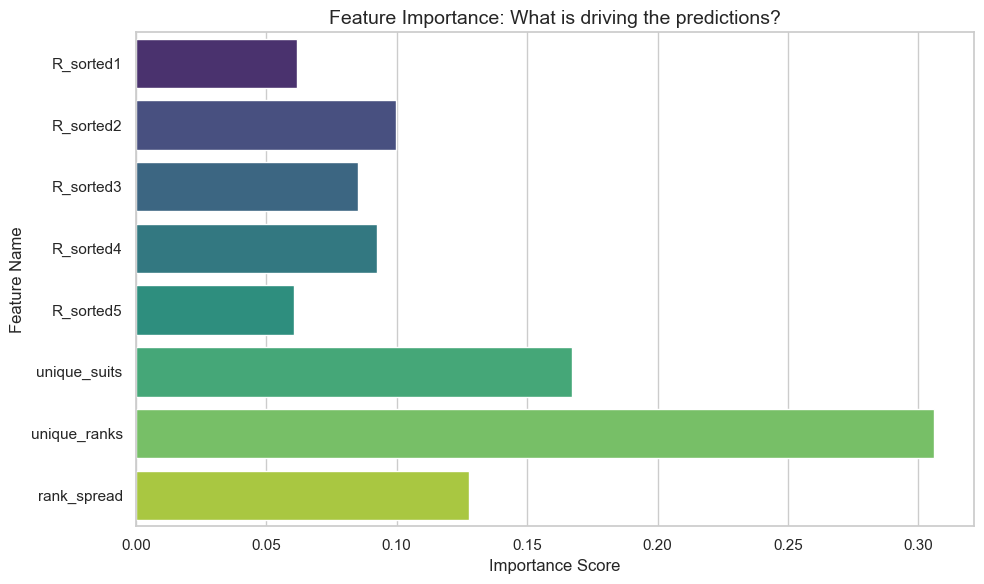

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
rf_model = pipeline.named_steps['clf']
feature_names = X_train.columns
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=feature_names, palette="viridis", hue=feature_names, legend=False)
plt.title('Feature Importance: What is driving the predictions?', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

Chart 2 (Confusion Matrix)

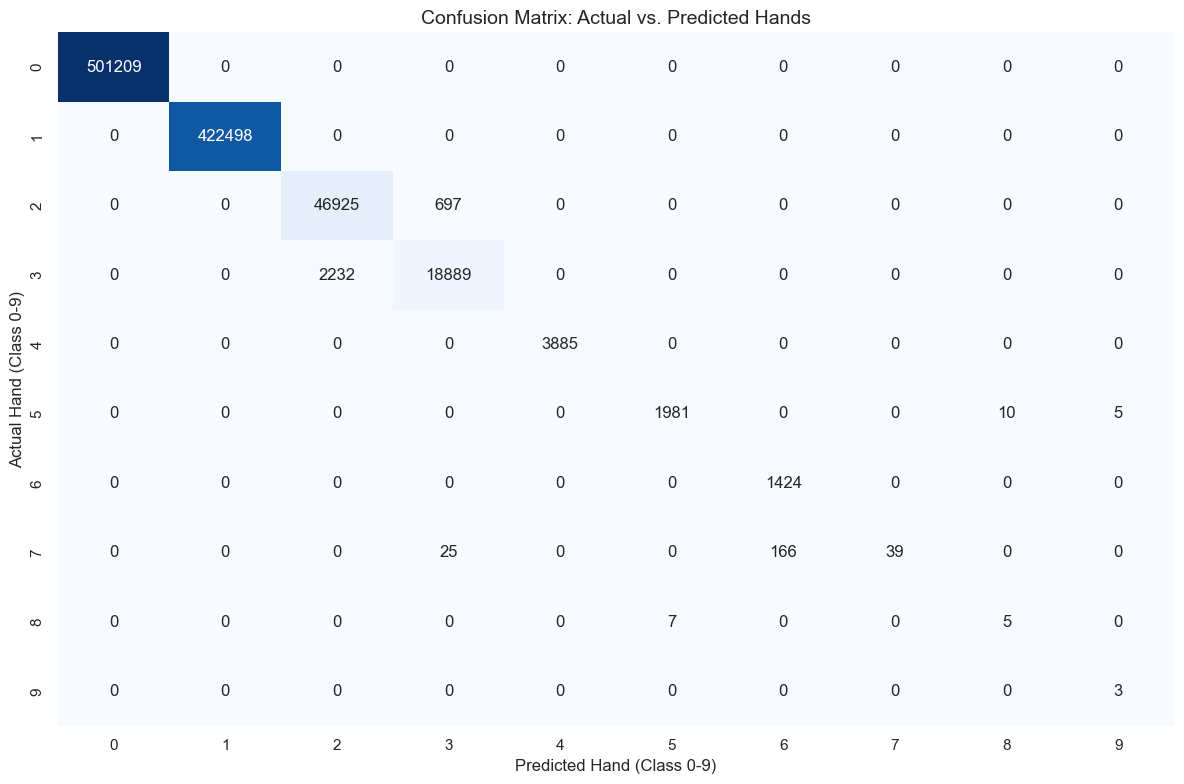

In [26]:
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix: Actual vs. Predicted Hands', fontsize=14)
plt.xlabel('Predicted Hand (Class 0-9)', fontsize=12)
plt.ylabel('Actual Hand (Class 0-9)', fontsize=12)
plt.tight_layout()
plt.show()